Analyzing flight delays using weather data

This project analyzes the relationship between weather conditions and flight delays using a large flight dataset.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Dataset Source

The dataset used in this project was obtained from a publicly available online flight delay dataset.
Source:
https://www.kaggle.com/datasets/threnjen/2019-airline-delays-and-cancellations

The original dataset contains over 6 million records. Due to its large size, it was uploaded to Google Drive and downloaded directly from a shared link. This allows the notebook to be run without manual downloads or file path modifications, ensuring that the results can be reproduced for all users.

In [2]:
file_id = "1YsNdOh6KN3rLtGRIA8dYFnwlRtvRlZsr"
url = f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)

In [3]:
#Data information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   MONTH                          500000 non-null  int64  
 1   DAY_OF_WEEK                    500000 non-null  int64  
 2   DEP_DEL15                      500000 non-null  int64  
 3   DEP_TIME_BLK                   500000 non-null  str    
 4   DISTANCE_GROUP                 500000 non-null  int64  
 5   SEGMENT_NUMBER                 500000 non-null  int64  
 6   CONCURRENT_FLIGHTS             500000 non-null  int64  
 7   NUMBER_OF_SEATS                500000 non-null  int64  
 8   CARRIER_NAME                   500000 non-null  str    
 9   AIRPORT_FLIGHTS_MONTH          500000 non-null  int64  
 10  AIRLINE_FLIGHTS_MONTH          500000 non-null  int64  
 11  AIRLINE_AIRPORT_FLIGHTS_MONTH  500000 non-null  int64  
 12  AVG_MONTHLY_PASS_AIRPORT       500000 non

Dataset Information

The original dataset contained 6,489,062 rows and 26 columns. Due to its large size (approximately 1.3 GB), a subset of 500,000 rows was extracted and uploaded to Google Drive to improve accessibility and processing efficiency.

The dataset used (500,000 rows) comprises 26 columns covering various characteristics of flight operations and weather. Numeric data, such as temperature, wind speed, precipitation, and snowfall, are stored as integer and decimal values, while categorical information, such as airport name and time period, is stored as text values. The memory used for this subset is approximately 99.2 MB.

In [4]:
df = df[[
    "MONTH",
    "DAY_OF_WEEK",
    "DEP_DEL15",
    "DEP_TIME_BLK",
    "DISTANCE_GROUP",
    "SEGMENT_NUMBER",
    "CONCURRENT_FLIGHTS",
    "CARRIER_NAME",
    "PLANE_AGE",
    "DEPARTING_AIRPORT",
    "PRCP",
    "SNOW",
    "SNWD",
    "TMAX",
    "AWND"
]]

Removal of Unnecessary Columns

Some columns were removed because they were not directly related to the impact of weather conditions on flight delays.

In [5]:
df.dropna(inplace=True)

Handling Missing Values

Missing values were removed to improve data quality.

In [6]:
df.drop_duplicates(inplace=True)

Removing Duplicate Rows

Duplicate rows were removed to avoid repeating information in the analysis.

In [7]:
df = df.sample(n=25000, random_state=42)

Sampling the Dataset

The original dataset was first reduced to a subset of 500,000 rows and then uploaded to Google Drive for easier access. Subsequently, a random sample of 25,000 rows was selected from this subset to expedite and improve the efficiency of the analysis.


In [8]:
df.describe()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,PLANE_AGE,PRCP,SNOW,SNWD,TMAX,AWND
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,6.617840,3.916280,0.189560,3.824240,3.046840,27.733480,11.458600,0.104361,0.032776,0.086512,71.394228,8.366052
std,3.403471,1.989409,0.391961,2.387848,1.760741,21.395427,6.941347,0.354111,0.329889,0.704143,18.375168,3.628573
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-10.000000,0.000000
25%,4.000000,2.000000,0.000000,2.000000,2.000000,11.000000,5.000000,0.000000,0.000000,0.000000,59.000000,5.820000
50%,7.000000,4.000000,0.000000,3.000000,3.000000,22.000000,12.000000,0.000000,0.000000,0.000000,74.000000,7.830000
75%,10.000000,6.000000,0.000000,5.000000,4.000000,38.000000,17.000000,0.020000,0.000000,0.000000,86.000000,10.510000
max,12.000000,7.000000,1.000000,11.000000,14.000000,109.000000,32.000000,11.630000,17.200000,20.100000,115.000000,32.440000


How do we interpret the statistical measures mentioned above?

Let's analyze these statistical measures to understand the distribution of flight delays and weather conditions in the dataset:

count (25,000):
This indicates that the dataset contains 25,000 flight records after preprocessing and sampling. This is a sufficient number of observations for meaningful analysis and modeling.

Mean:
The mean provides the overall average for each characteristic. For example, the mean delay index (DEP_DEL15 ≈ 0.189560) indicates that approximately 19% of flights experienced delays of more than 15 minutes, while the majority of flights were on time.

The mean temperature (TMAX ≈ 71.3) shows that most flights took place in moderate weather conditions.

Standard Deviation:
The standard deviation measures how much the values vary around the mean. For example, a large variability in the number of simultaneous flights and weather variables indicates that the dataset encompasses a range of operational and atmospheric conditions, from low to high traffic and from calm to severe weather.

Minimum values:
Minimum values represent the lowest recorded values. For example, a minimum temperature of -10°C indicates that some flights took place in extremely cold weather conditions, while zero values for precipitation and snow indicate normal weather conditions.

25%:
This means that 25% of the data fall below these values. For example, 25% of flights experienced low traffic levels and minimal weather impact, indicating generally stable conditions for a large portion of the flights.

Medium (50%):
The median represents the middle value of the dataset. It is often more accurate than the mean. For example, a median delay index of zero confirms that more than half of the flights were not delayed.

75%:
This indicates that 75% of observations fall below these values. This helps to understand the upper range of normal operating and weather conditions.

Extreme Values:
Extreme values highlight extreme weather conditions in the dataset. For example, heavy rainfall (11.63) and high wind speed (32.4) indicate that the dataset includes rare but significant weather events that may contribute to flight delays.

General Interpretation:
The dataset shows a realistic mix of normal and extreme flight and weather conditions. Most flights arrive on time, but weather variables, such as rain, snow, and wind speed, are expected to play a significant role in explaining delay behavior.

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 25000 entries, 239691 to 128050
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MONTH               25000 non-null  int64  
 1   DAY_OF_WEEK         25000 non-null  int64  
 2   DEP_DEL15           25000 non-null  int64  
 3   DEP_TIME_BLK        25000 non-null  str    
 4   DISTANCE_GROUP      25000 non-null  int64  
 5   SEGMENT_NUMBER      25000 non-null  int64  
 6   CONCURRENT_FLIGHTS  25000 non-null  int64  
 7   CARRIER_NAME        25000 non-null  str    
 8   PLANE_AGE           25000 non-null  int64  
 9   DEPARTING_AIRPORT   25000 non-null  str    
 10  PRCP                25000 non-null  float64
 11  SNOW                25000 non-null  float64
 12  SNWD                25000 non-null  float64
 13  TMAX                25000 non-null  float64
 14  AWND                25000 non-null  float64
dtypes: float64(5), int64(7), str(3)
memory usage: 3.1 MB


All variables have data types suitable for analysis. Numerical data are stored correctly as integers and decimals, while categorical data, such as airport names and time periods, are stored as text. This makes the dataset suitable for further preprocessing and analysis.

In [10]:
df.isnull().sum()

MONTH                 0
DAY_OF_WEEK           0
DEP_DEL15             0
DEP_TIME_BLK          0
DISTANCE_GROUP        0
SEGMENT_NUMBER        0
CONCURRENT_FLIGHTS    0
CARRIER_NAME          0
PLANE_AGE             0
DEPARTING_AIRPORT     0
PRCP                  0
SNOW                  0
SNWD                  0
TMAX                  0
AWND                  0
dtype: int64

No missing values were found after preprocessing, which improves data reliability.

In [11]:
df.duplicated().sum()

np.int64(0)

Duplicate rows were removed to avoid bias in the analysis.

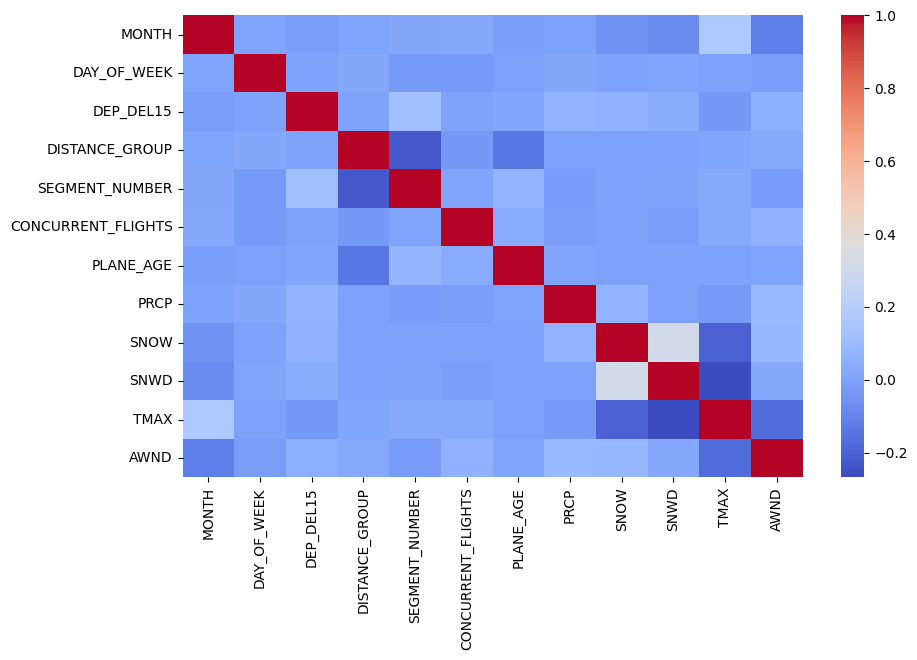

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.show()

Correlation analysis helps identify relationships between weather variables and flight delay patterns.

In [13]:
df["DEP_DEL15"].value_counts()

DEP_DEL15
0    20261
1     4739
Name: count, dtype: int64

Flight Delay Distribution (DEP_DEL15)

The target variable DEP_DEL15 represents whether a flight was delayed by more than 15 minutes (1 = delayed, 0 = not delayed).

Results:

- 20,261 flights were not delayed (approximately 81.0%).
-4,739 flights were delayed (approximately 19.0%).

This indicates an imbalance in the dataset, as the majority of flights arrive on time, while a smaller percentage are delayed.

This imbalance is important for future analysis and modeling, as it may affect the performance of prediction models and should be considered during model development.

In [14]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).sum()

outliers

MONTH                    0
DAY_OF_WEEK              0
DEP_DEL15             4739
DISTANCE_GROUP        1280
SEGMENT_NUMBER         388
CONCURRENT_FLIGHTS     778
PLANE_AGE                0
PRCP                  5241
SNOW                   627
SNWD                   624
TMAX                    86
AWND                   499
dtype: int64

Detecting Outliers Using the Interquartile Range Method

This step identifies the number of outliers (outliers) in each numerical property using the Interquartile Range (IQR) method. Outliers are values ​​that fall significantly outside the normal distribution of the data.

Results:

- Several properties, such as PRCP, SNOW, SNWD, and AWND, contain a significant number of outliers, which is expected given the wide variation in weather conditions and the likelihood of extreme weather events.

- The CONCURRENT_FLIGHTS and DISTANCE_GROUP properties also show some outliers, indicating variations in air traffic at airports and flight distances.

- Basic calendar properties, such as MONTH and DAY_OF_WEEK, show no outliers or very few, which is expected given their consistent ranges.

The presence of outliers in the PLANE_AGE and TMAX properties indicates variations in aircraft age and temperature conditions across different flights.

Overall, the dataset contains a reasonable number of outliers, particularly in weather-related variables. These outliers are significant because they may represent real-world weather events that directly impact flight delays and should therefore only be discarded after careful consideration.

Experimentation and Visualization


Histogram

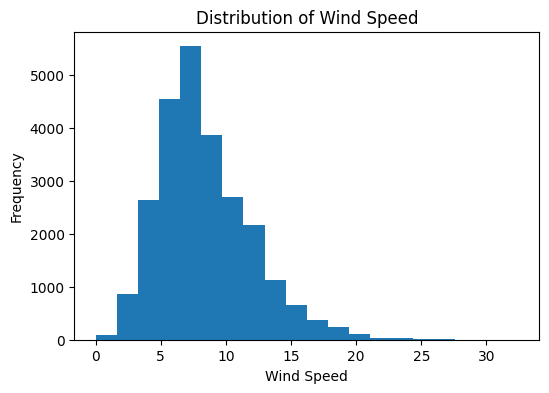

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['AWND'], bins=20)
plt.title('Distribution of Wind Speed')
plt.xlabel('Wind Speed')
plt.ylabel('Frequency')
plt.show()

The histogram shows the distribution of wind speed values in the dataset. Most flights were operated under moderate wind conditions, while extremely high wind speeds occurred less frequently.

Boxplot

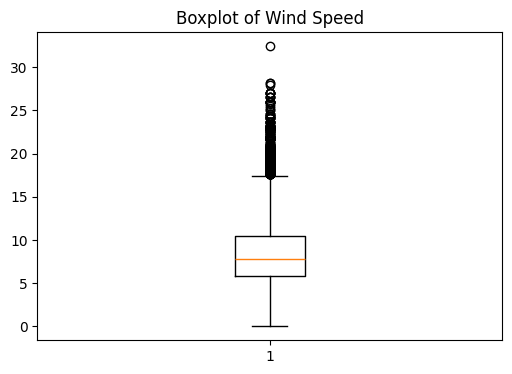

In [16]:
plt.figure(figsize=(6,4))
plt.boxplot(df['AWND'])
plt.title('Boxplot of Wind Speed')
plt.show()

The boxplot highlights the spread of wind speed values and identifies potential outliers. Some flights experienced unusually high wind speeds compared to the majority of observations.

Scatter Plot

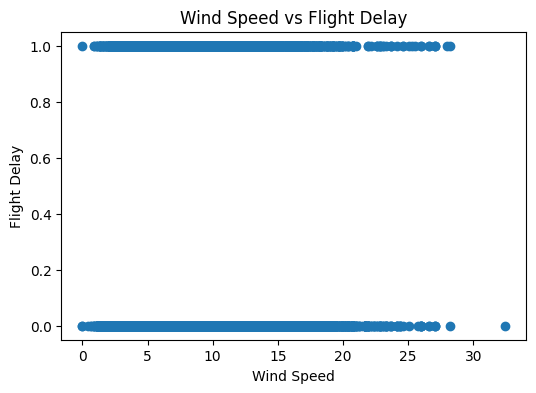

In [17]:
plt.figure(figsize=(6,4))
plt.scatter(df['AWND'], df['DEP_DEL15'])
plt.xlabel('Wind Speed')
plt.ylabel('Flight Delay')
plt.title('Wind Speed vs Flight Delay')
plt.show()

The scatter plot illustrates the relationship between wind speed and flight delays. Flights operating under stronger wind conditions appear more likely to experience delays.

Prediction

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = df[['AWND','PRCP','TMAX','PLANE_AGE','CONCURRENT_FLIGHTS']]
y = df['DEP_DEL15']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.6908


Prediction Explanation

A Decision Tree classifier was used to predict whether a flight would be delayed based on weather and operational factors. The model was trained using wind speed, precipitation, temperature, aircraft age, and concurrent flights. The resulting accuracy demonstrates the effectiveness of these variables in predicting flight delays.

Conclusion

The experimental results indicate that weather and operational factors influence flight delays. Wind speed and precipitation showed noticeable effects on delay occurrence. Furthermore, the prediction model achieved reasonable accuracy, demonstrating the usefulness of machine learning techniques in forecasting flight delays.

-------------------------------------------
Phase 4 - Final Machine Learning Model

Characteristics and Target Variable Selection

The input characteristics were selected based on the results of the previous phase, which indicated that both weather conditions and airport operational pressures could affect flight delays. The selected predictive variables are:

- Average Wind Speed ​​(AWND)
- Precipitation Amount (PRCP)
- Maximum Temperature (TMAX)
- Aircraft Age (PLANE_AGE)
- Concurrent Flight Time (CONCURRENT_FLIGHTS)

The target variable is:

- Departure Delay Exceeding 15 Minutes (DEP_DEL15)

These characteristics were chosen because of their direct correlation with the severity of weather conditions and air traffic, both of which can contribute to flight disruptions.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[['AWND', 'PRCP', 'TMAX', 'PLANE_AGE', 'CONCURRENT_FLIGHTS']]
y = df['DEP_DEL15']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,  # Number of decision trees
    max_depth=10,  # Maximum tree depth
    random_state=42,  # Reproducible results
    class_weight='balanced'  # Handle class imbalance
)
# Train the model

rf_model.fit(X_train, y_train)
# Generate predictions on test data

rf_predictions = rf_model.predict(X_test)


To further understand flight delay prediction, a random forest classifier was used as an alternative to the initial decision tree model developed in Phase III. The random forest classifier combines several decision trees to improve prediction stability and reduce the risk of over-allocation.

The dataset was divided into two subsets: a training subset and a test subset, at 80% and 20% respectively. Stratified sampling was used to maintain the original distribution of delayed and non-delayed flights in both subsets, given the data imbalance. The model was tuned with 100 trees (n_estimators = 100), a maximum depth of 10 (max_depth = 10), and balanced class weights to minimize the impact of class imbalance. A random state of 42 was used to ensure the reproducibility of the results.

In [20]:
from sklearn.metrics import classification_report

# Check the model on training data
train_predictions = rf_model.predict(X_train)
print("Classification Report: Train Data")
print(classification_report(y_train, train_predictions))

# Check the model on test data (already computed as rf_predictions)
print("Classification Report: Test Data")
print(classification_report(y_test, rf_predictions))

Classification Report: Train Data
              precision    recall  f1-score   support

           0       0.89      0.84      0.86     16209
           1       0.44      0.55      0.49      3791

    accuracy                           0.78     20000
   macro avg       0.66      0.69      0.68     20000
weighted avg       0.80      0.78      0.79     20000

Classification Report: Test Data
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      4052
           1       0.25      0.32      0.28       948

    accuracy                           0.69      5000
   macro avg       0.54      0.55      0.54      5000
weighted avg       0.72      0.69      0.70      5000



In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score
accuracy_dt = accuracy_score(y_test, dt_predictions)
precision_dt = precision_score(y_test, dt_predictions)
recall_dt = recall_score(y_test, dt_predictions)
f1_dt = f1_score(y_test, dt_predictions)
print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)

Accuracy: 0.6902
Precision: 0.20796890184645286
Recall: 0.22573839662447256
F1 Score: 0.21648963075366717


The decision tree model was evaluated using the same stratified data structure for training and testing as the random forest model to ensure a fair comparison. Several evaluation metrics were calculated to assess its performance, particularly given the dataset imbalance.
The results were as follows:
Accuracy: 0.6902
Fineness: 0.208
Recall: 0.226
F1 score: 0.216
These results indicate that the decision tree model has limited ability to accurately identify delayed flights. The low values ​​for fineness, recall, and F1 demonstrate that the model struggles to effectively detect delayed flights.
Compared to the decision tree model, the random forest model achieved higher accuracy (0.25 vs. 0.21), higher recall (0.32 vs. 0.23), and a higher F1 score (0.28 vs. 0.22), while maintaining nearly identical overall accuracy (69.04% vs. 69.02%). This improvement is expected because the random forest model combines several decision trees, which increases the model's stability and reduces the risk of over-allocation compared to using a single decision tree.

In [23]:
from sklearn.metrics import accuracy_score

# Accuracy = (TP + TN) / Total
accuracy = accuracy_score(y_test, rf_predictions)
print("Accuracy:", accuracy)

Accuracy: 0.6904


The random forest classifier achieved an accuracy of 69.04%, meaning the model correctly predicted the flight delay state for approximately 69% of the observations in the test set. However, due to the imbalance of the data set, accuracy should be interpreted in conjunction with precision, recall, and F1 metric to obtain a more reliable assessment of the model's performance.

In [24]:
from sklearn.metrics import recall_score
# Recall = TP / (TP + FN)
recall = recall_score(y_test, rf_predictions)
print("Recall:", recall)

Recall: 0.3206751054852321


The random forest model achieved a recall rate of 0.321 (32.1%), indicating that the model correctly identified only one-third of the actual delayed flights. In other words, a significant proportion of the delayed flights were incorrectly classified as not delayed.

This confusion matrix confirms this finding. Of the 948 actually delayed flights, the model correctly identified 304, while 644 were incorrectly classified as not delayed (false negatives). The large number of false negatives suggests that the model's ability to detect delayed flights is limited, despite its average overall accuracy.

In practice, this limitation reduces the model's usefulness in predicting delays, as many actual delays will go undetected. The relatively low recall rate may be attributed to an imbalance of classes in the dataset, where the number of not delayed flights significantly exceeds the number of delayed flights, making it difficult for the model to learn the patterns associated with the smaller class.

In [25]:
from sklearn.metrics import precision_score

# Precision = TP / (TP + FP)
precision = precision_score(y_test, rf_predictions)
print("Precision:", precision)

Precision: 0.25165562913907286


The random forest model achieved an accuracy of 0.252 (25.2%), indicating that only a quarter of the flights predicted to be delayed actually did. In other words, a significant proportion of the delay predictions were incorrect.

This result is corroborated by the confusion matrix. The model predicted delays for 1,208 flights, of which only 304 were correctly classified (true positives), while 904 were incorrectly classified (false positives). This high number of false positives suggests that the model generated numerous false alarms.

Operationally, the low accuracy reduces the reliability of the model's delay predictions. Airport operators and airlines relying on these predictions may unnecessarily allocate resources or make operational adjustments to flights that will ultimately depart on schedule. Therefore, while the model was able to identify some delayed flights, its ability to accurately distinguish between delayed and non-delayed flights remained limited.

In [26]:
from sklearn.metrics import f1_score

# F1 = Harmonic mean of Precision and Recall
f1 = f1_score(y_test, rf_predictions)
print("F1 Score:", f1)

F1 Score: 0.2820037105751391


F1 Score Analysis
The random forest model achieved an F1 score of 0.282 (28.2%), indicating relatively poor performance in identifying late flights. The F1 score represents the harmonic mean of accuracy and recall and is particularly useful when evaluating models on unbalanced datasets, as it accounts for both false positives and false negatives.

The low F1 score is directly attributable to the model's low accuracy (25.2%) and recall (32.1%). Although the model was able to identify some late flights, it produced a large number of false delay predictions and failed to detect many actual delays. Consequently, the balance between accurately identifying late flights and minimizing classification errors remained limited.

Given the unbalanced categories in the dataset, the F1 score provides a more comprehensive assessment than accuracy alone. The obtained value indicates that the model's predictive power for the late flight category is still inadequate and could be improved with additional predictive features, a larger dataset, or alternative modeling approaches.

In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.83      0.78      0.80      4052
           1       0.25      0.32      0.28       948

    accuracy                           0.69      5000
   macro avg       0.54      0.55      0.54      5000
weighted avg       0.72      0.69      0.70      5000



The ranking report shows that the model performs better when predicting Category 0 (non-delayed flights) compared to Category 1 (delayed flights).

For Category 0, the model achieved an accuracy of 0.83, a recall of 0.78, and an F1 score of 0.80, indicating its relatively good ability to identify non-delayed flights.

However, for Category 1, the performance is significantly lower. The model achieved an accuracy of 0.25, a recall of 0.32, and an F1 score of 0.28. This means the model struggles to detect delayed flights and misses many.

The 69% accuracy does not accurately reflect the model's true performance due to the imbalance in the dataset. There are more non-delayed flights (4052) than delayed flights (948), making the model more likely to predict Category 0 flights.

Overall, the model demonstrates good ability to distinguish non-delayed flights but needs improvement in detecting delayed flights. Techniques such as data balancing or model modification may contribute to improving the accuracy of its delayed flight predictions.

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_predictions)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[3148  904]
 [ 644  304]]


The confusion matrix demonstrates the model's ability to distinguish between non-delayed and non-delayed flights.

The model correctly classified 3,148 non-delayed flights and 304 delayed flights. This indicates the model's ability to detect both types.

However, the model also recorded 904 false positives, where non-delayed flights were classified as delayed. Additionally, it recorded 644 false negatives, where delayed flights were classified as non-delayed.

The high number of false negatives is a significant problem, as the model fails to identify many genuinely delayed flights. This reduces the model's practical value, especially when the goal is to detect delays before they occur.

Overall, the confusion matrix confirms that the model is better at predicting non-delayed flights than delayed flights, primarily due to the imbalance between the two types.

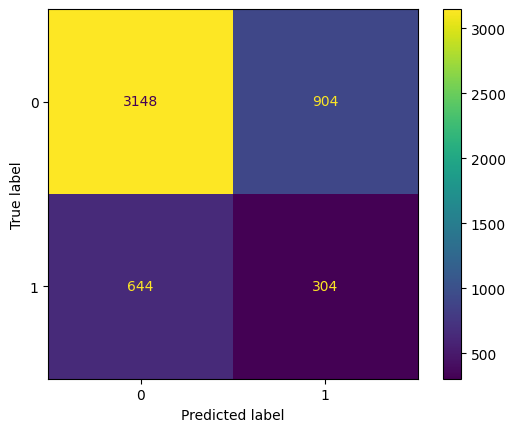

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, rf_predictions)

The confusion matrix evaluates the performance of a classification model by comparing the actual flight status with the predicted outcomes.

The model correctly classified 3,148 non-delayed flights (true negative), meaning that most non-delayed flights were correctly identified. This demonstrates the model's good ability to distinguish non-delayed flights.

Conversely, the model incorrectly predicted 904 non-delayed flights as delayed (false positive). This means that the model may sometimes issue false warnings about delays that do not actually occur.

As for delayed flights, the model correctly classified 304 delayed flights (true positive). This shows the model's ability to identify some delayed flights, although this number is relatively low compared to the total number of delays.

However, the model failed to detect 644 delayed flights (false negative), where flights that were actually delayed were incorrectly classified as non-delayed. This is a significant problem because failing to detect actual delays reduces the reliability of the prediction system.

Overall, the confusion matrix shows that the model performs better at identifying non-delayed flights than delayed flights. The large number of false negatives indicates that the model needs improvement in detecting delays, which is likely related to the imbalance between the two categories in the dataset.

In [30]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

              Feature  Importance
2                TMAX    0.221964
1                PRCP    0.210544
4  CONCURRENT_FLIGHTS    0.206555
0                AWND    0.199244
3           PLANE_AGE    0.161693


The feature significance results show how each feature contributes to the random forest model's flight delay predictions.

The maximum temperature (TMAX) is the most significant feature, with a significance of 0.222, indicating that temperature has the greatest impact on the model's predictions.

Next in significance is the precipitation feature (PRCP), with a significance of 0.211, suggesting that weather conditions, particularly rain, have a strong influence on delay predictions.

The number of simultaneous flights (CONCURRENT_FLIGHTS) has a significance of 0.207, indicating that the number of flights operating at the same time also affects delay predictions, possibly due to airport congestion.

The average wind speed (AWND) has a significance of 0.199, meaning that wind conditions also contribute to flight delay predictions.

Finally, the aircraft age (PLANE_AGE) is the least significant feature (0.162) but still influences the model.

Overall, the results indicate that weather-related features are the most influential factors in predicting flight delays, followed by airport traffic and aircraft age.

In [31]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree (Phase 3)', 'Random Forest (Phase 4)'],
    'Accuracy': [accuracy_dt, accuracy],
    'Precision': [precision_dt, precision],
    'Recall': [recall_dt, recall],
    'F1-Score': [f1_dt, f1]
})
print(comparison)

                     Model  Accuracy  Precision    Recall  F1-Score
0  Decision Tree (Phase 3)    0.6902   0.207969  0.225738  0.216490
1  Random Forest (Phase 4)    0.6904   0.251656  0.320675  0.282004


A comparison between the decision tree and random forest models shows that both achieved very similar overall accuracy when evaluated using the same stratified data segmentation (training/testing).
The decision tree model achieved an accuracy of 69.02%, while the random forest model achieved a slightly higher accuracy of 69.04%.
Although the difference in overall accuracy was very small, the random forest model achieved higher accuracy (0.25 vs. 0.21), higher recall (0.32 vs. 0.23), and a higher F1 score (0.28 vs. 0.22) in detecting delayed flights.
These results indicate that accuracy alone is insufficient to evaluate models on an unbalanced dataset. The improvements in accuracy, recall, and F1 score demonstrate that the random forest model is more effective at identifying delayed flights while maintaining similar overall accuracy.
Overall, the random forest model offers better predictive performance for delayed flights and was therefore selected as the final model for this project.

# Final Conclusion

The Random Forest Classifier was selected as the ultimate machine learning model for predicting flight delays. The model was evaluated using accuracy, fine-tuning, recall, F1 metric, and confusion matrix.

The model achieved an overall accuracy of 69.04%. While its overall accuracy was very similar to that of the Decision Tree model (69.02%), it achieved higher accuracy, recall, and F1 metric in detecting delayed flights. This demonstrates that the Random Forest is more effective at identifying delayed flights while maintaining similar overall accuracy.

The analysis showed that weather conditions, particularly extreme temperature and rainfall, are significant factors influencing flight delay predictions. Airport traffic congestion, wind conditions, and aircraft age also contributed to the model's predictions.

Although the model provides useful predictions, its ability to detect delayed flights can be further improved through data balancing techniques, feature engineering, and testing of more advanced machine learning models.